# Clustering

## Import Library

In [1]:
import joblib
import json
import pandas as pd
import numpy as np
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

## Load Datasets

In [2]:
df = pd.read_csv('data/dataset/cleaned.csv')
df.head()

,cpu_usage,memory_usage,temperature,battery_drain,battery_charging,upload_speed_kbps,download_speed_kbps,screen_on
0,1.147751,-0.022174,-0.776643,0.330735,0,-0.907048,-0.634519,1
1,1.972228,-0.022174,-0.776643,-0.402312,0,3.482663,2.587398,1
2,-0.243555,-0.022174,-0.776643,0.396874,0,-0.421329,-0.630424,1
3,-0.707324,-0.022174,-0.776643,0.766153,0,0.103522,-0.625933,1
4,-0.707324,0.439932,-0.776643,0.793711,0,-0.012596,-0.607760,1


In [3]:
df.describe()

,cpu_usage,memory_usage,temperature,battery_drain,battery_charging,upload_speed_kbps,download_speed_kbps,screen_on
count,1.042000e+03,1.042000e+03,1.042000e+03,1.042000e+03,1042.0,1.042000e+03,1042.000000,1042.0
mean,-2.182089e-16,7.091789e-16,2.454850e-15,-2.182089e-16,0.0,6.478077e-17,0.000000,1.0
std,1.000480e+00,1.000480e+00,1.000480e+00,1.000480e+00,0.0,1.000480e+00,1.000480,0.0
min,-1.583331e+00,-3.256917e+00,-1.565334e+00,-3.411660e+00,0.0,-9.070483e-01,-0.634519,1.0
25%,-9.649730e-01,-7.153332e-01,-1.105264e+00,-8.487535e-01,0.0,-7.616075e-01,-0.632055,1.0
50%,-2.177902e-01,-2.217400e-02,2.092200e-01,3.197114e-01,0.0,-3.286220e-01,-0.610762,1.0
75%,8.901014e-01,9.020382e-01,6.692895e-01,8.488276e-01,0.0,3.807739e-01,0.806057,1.0
max,2.332937e+00,1.595197e+00,2.641016e+00,1.973199e+00,0.0,4.277705e+00,3.246710,1.0


In [4]:
df_dropped = df.drop(columns=['battery_charging', 'screen_on'])

## Clustering

### K-Means

#### Training

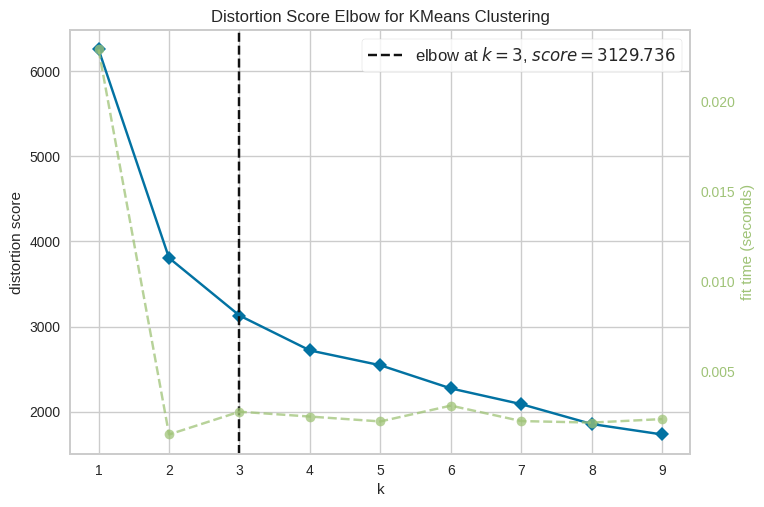

3


In [5]:
X = df_dropped.select_dtypes(include=['float64','int64']).to_numpy()
model = KMeans(random_state=42)

visualizer = KElbowVisualizer(
    model,
    k=(1,10),
    force_model=True
)

visualizer.fit(X)
visualizer.show()
best_k = visualizer.elbow_value_
print(best_k)

In [6]:
model_kmeans = KMeans(n_clusters=2, random_state=42)
labels_kmeans = model_kmeans.fit_predict(X)
df_kmeans = df_dropped.copy()

df_kmeans['Target'] = labels_kmeans
df_kmeans.head()

,cpu_usage,memory_usage,temperature,battery_drain,upload_speed_kbps,download_speed_kbps,Target
0,1.147751,-0.022174,-0.776643,0.330735,-0.907048,-0.634519,0
1,1.972228,-0.022174,-0.776643,-0.402312,3.482663,2.587398,0
2,-0.243555,-0.022174,-0.776643,0.396874,-0.421329,-0.630424,1
3,-0.707324,-0.022174,-0.776643,0.766153,0.103522,-0.625933,1
4,-0.707324,0.439932,-0.776643,0.793711,-0.012596,-0.607760,1


In [7]:
df_kmeans.to_csv('data/result/kmeans.csv', index=False)

In [8]:
joblib.dump(model_kmeans, 'model/kmeans_model.pkl')

['model/kmeans_model.pkl']

#### Evaluation

In [9]:
silhouette_score(X, df_kmeans['Target'])

0.38181934835062686

In [10]:
davies_bouldin_score(X, df_kmeans['Target'])

1.1366800480688033

In [11]:
calinski_harabasz_score(X, df_kmeans['Target'])

668.5845615234645

### DBScan

#### Training

In [12]:
df_dbscan = df_dropped.copy()
X_dbscan = df.select_dtypes(include=['float64','int64']).to_numpy()
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5,
)

labels_dbscan = dbscan.fit_predict(X)
df_dbscan["Target"] = labels_dbscan
df_dbscan.head()

,cpu_usage,memory_usage,temperature,battery_drain,upload_speed_kbps,download_speed_kbps,Target
0,1.147751,-0.022174,-0.776643,0.330735,-0.907048,-0.634519,-1
1,1.972228,-0.022174,-0.776643,-0.402312,3.482663,2.587398,-1
2,-0.243555,-0.022174,-0.776643,0.396874,-0.421329,-0.630424,-1
3,-0.707324,-0.022174,-0.776643,0.766153,0.103522,-0.625933,-1
4,-0.707324,0.439932,-0.776643,0.793711,-0.012596,-0.607760,-1


In [13]:
df_dbscan.to_csv("data/result/dbscan.csv", index=False)

In [14]:
joblib.dump(dbscan, 'model/dbscan_model.pkl')

['model/dbscan_model.pkl']

### Analysis

In [15]:
silhouette_score(X_dbscan, df_dbscan['Target'])

-0.0926239178682985

In [16]:
davies_bouldin_score(X_dbscan, df_dbscan['Target'])

1.2813133525261582

In [17]:
calinski_harabasz_score(X_dbscan, df_dbscan['Target'])

50.36544656059916

## PCA

### Training

In [18]:
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X)

PCA_numbers = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2', 'PCA3'])

kmeans_pca = KMeans(n_clusters=2, random_state=42)
labels_pca = kmeans_pca.fit_predict(X_pca)

In [20]:
print(pca.components_)

[[-0.51907626 -0.52642206 -0.40485634  0.52790602  0.06538494  0.081062  ]
 [ 0.08152387  0.02038338 -0.05513579 -0.13531952  0.69102492  0.70290227]
 [-0.22105072 -0.0865657   0.69545552  0.22429984  0.51484939 -0.38026867]]


In [22]:
with open("data/scaler.json") as f:
    params = json.load(f)

params["components"] = pca.components_.tolist()
params["explained_variance"] = pca.explained_variance_ratio_.tolist()

with open("data/scaler.json", "w") as f:
    json.dump(params, f, indent=4)

In [23]:
PCA_numbers['Target'] = labels_pca
PCA_numbers.head()

,PCA1,PCA2,PCA3,Target
0,-0.205814,-0.981615,-0.943434,0
1,-0.472564,4.482888,-0.255262,0
2,0.583386,-0.765467,-0.372535,1
3,1.053743,-0.487404,0.081322,1
4,0.818909,-0.549180,-0.019193,1


In [37]:
PCA_numbers.to_csv("data/result/pca_kmeans.csv", index=False)

In [25]:
joblib.dump(kmeans_pca, 'model/pca_model.pkl')

['model/pca_model.pkl']

### Analysis

In [26]:
silhouette_score(X_pca, PCA_numbers['Target'])

0.46589589019652744

In [27]:
davies_bouldin_score(X_pca, PCA_numbers['Target'])

0.9105876144929699

In [28]:
calinski_harabasz_score(X_pca, PCA_numbers['Target'])

998.3105084570236

## Analysis (PCA)

In [33]:
cluster_analysis = PCA_numbers.groupby('Target').agg(['mean', 'min', 'max'])
cluster_analysis

PCA1                          PCA2                          PCA3  \
            mean       min       max      mean       min       max      mean   
Target                                                                         
0      -1.634445 -3.397819 -0.006314  0.042378 -1.408473  4.482888 -0.032086   
1       1.434189 -0.108187  2.676710 -0.037186 -1.394686  3.707573  0.028155   

                            
             min       max  
Target                      
0      -2.102008  3.179061  
1      -1.944213  3.450022

### Inverse

In [30]:
with open("data/scaler.json") as f:
    scaler_params = json.load(f)

mean = np.array(scaler_params['mean'])
scale = np.array(scaler_params['scale'])

In [31]:
X_scaled = df_dropped.values
X_original = X_scaled * scale + mean

df_original = pd.DataFrame(
    X_original,
    columns=df_dropped.columns
)
df_original.head()

,cpu_usage,memory_usage,temperature,battery_drain,upload_speed_kbps,download_speed_kbps
0,77.0,75.0,33.2,-308.0,0.000000,0.000000
1,93.0,75.0,33.2,-441.0,7.612117,111.012924
2,50.0,75.0,33.2,-296.0,0.842276,0.141110
3,41.0,75.0,33.2,-229.0,1.752412,0.295840
4,41.0,77.0,33.2,-224.0,1.551054,0.921999


In [32]:
df_original['Target'] = PCA_numbers['Target']
df_original.head()

,cpu_usage,memory_usage,temperature,battery_drain,upload_speed_kbps,download_speed_kbps,Target
0,77.0,75.0,33.2,-308.0,0.000000,0.000000,0
1,93.0,75.0,33.2,-441.0,7.612117,111.012924,0
2,50.0,75.0,33.2,-296.0,0.842276,0.141110,1
3,41.0,75.0,33.2,-229.0,1.752412,0.295840,1
4,41.0,77.0,33.2,-224.0,1.551054,0.921999,1


In [34]:
df_original.to_csv("data/original_pca.csv", index=False)

In [35]:
cluster_analysis = df_original.groupby('Target').agg(['mean', 'min', 'max'])
df_analysis = cluster_analysis.reset_index()
df_analysis.head()

Target  cpu_usage              memory_usage             temperature        \
               mean   min    max         mean   min   max        mean   min   
0      0  71.078029  32.0  100.0    78.915811  69.0  82.0   35.364066  32.0   
1      1  40.378378  24.0  100.0    71.744144  61.0  79.0   33.519640  32.0   

        battery_drain              upload_speed_kbps                 \
    max          mean    min   max              mean  min       max   
0  38.4   -525.414784 -987.0 -82.0          1.393204  0.0  8.844257   
1  38.4   -229.884685 -814.0 -10.0          1.730571  0.0  8.990784   

  download_speed_kbps                  
                 mean  min        max  
0           19.191334  0.0  133.72989  
1           24.206781  0.0  129.80138

In [36]:
df_analysis.to_csv("data/cluster_analysis.csv", index=False)

## Interpretation
### Introduction
Based on the result of the K-Means clustering process, the model produce two cluster (K = 2) representing different device workload conditions. The number of cluster is based on the Elbow Method analysis, which indicated the optimal number of cluster is 3 clusters, but after verifying the number of cluster, it was concluded that the number of clusters chosen is 2 because of its high metrics evaluation. The clustering process utilized the following features:
- CPU Usage (%)
- Memory Usage (%)
- Temperature (°C)
- Battery Current (mA)
- Upload Speed (kbps)
- Download Speed (kbps)

### Cluster Characteristic
#### Label 0 (High Load Condition)
Cluster 0 represent period of high device workload characterized by:

- Higher average CPU and Memory usage compare to other clusters
- Higher battery drain due to its need to power more the CPU
- Average Network Consumption

This condition typically occurs during resource-intensive activities such as gaming or multitasking applications that require significant processing power
#### Label 1 (Low Load Condition)
Cluster 1 represent periods of low device workload characterized by:

- Lower CPU and Memory usage compare to other clusters
- Lower battery drain due to its lack of hardware usage
- Higher network usage in terms of upload and download

This condition commonly occurs during activities such as social media browsing or video streaming (e.g., YouTube or TikTok), where network usage is dominant but processing demand remains low.

### Clustering Validation
To evaluate the clustering quality, the following validation metrics were used:

- Silhouette Score: 0.46
- Davies Bouldin Index: 0.91
- Calinski Harabasz Score: 998.31